In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# Lecture du fichier
df = pd.read_csv("../dataset/etudiant_multi_var.csv")
df = df.dropna()

# --- PRÉPARATION DES DONNÉES ---
# On récupère nos colonnes X et on ajoute une colonne de "1" pour l'Intercept (le 'b')
X = df[['Heures', 'Sommeil', 'Stress', 'Participation', 'Sport', 'Ecran']].values
y = df['Note'].values.reshape(-1, 1)


In [4]:
# On ajoute une colonne de 1 à gauche de X pour gérer le biais (intercept) facilement
X_bias = np.c_[np.ones((X.shape[0], 1)), X]


n_colonnes = X_bias.shape[1]
poids = np.zeros((n_colonnes, 1))  # On commence avec des coefficients à 0
vitesse_apprentissage = 0.0001     # Le "pas" pour avancer vers la solution
iterations = 10000                 # Combien de fois on ajuste les poids



In [5]:
for i in range(iterations):
    # 1. On calcule la prédiction actuelle
    predictions = np.dot(X_bias, poids)

    # 2. On calcule l'erreur (différence entre réalité et prédiction)
    erreur = predictions - y

    # 3. On calcule le "gradient" (dans quel sens on doit modifier les poids)
    gradient = (2 / len(y)) * np.dot(X_bias.T, erreur)

    # 4. On met à jour les poids en allant dans le sens inverse de l'erreur
    poids = poids - (vitesse_apprentissage * gradient)


intercept = poids[0][0]
coeffs = poids[1:].flatten()

print("=== RÉGRESSION MULTIPLE (FAITE À LA MAIN) ===")
print(f"Note de départ (Biais) : {intercept:.4f}")
noms_colonnes = ['Heures', 'Sommeil', 'Stress', 'Participation', 'Sport', 'Ecran']
for nom, val in zip(noms_colonnes, coeffs):
    print(f"Impact de {nom} : {val:.4f}")



=== RÉGRESSION MULTIPLE (FAITE À LA MAIN) ===
Note de départ (Biais) : 0.0235
Impact de Heures : 0.0242
Impact de Sommeil : 0.0966
Impact de Stress : 0.1925
Impact de Participation : 0.2399
Impact de Sport : -0.0315
Impact de Ecran : 0.2781


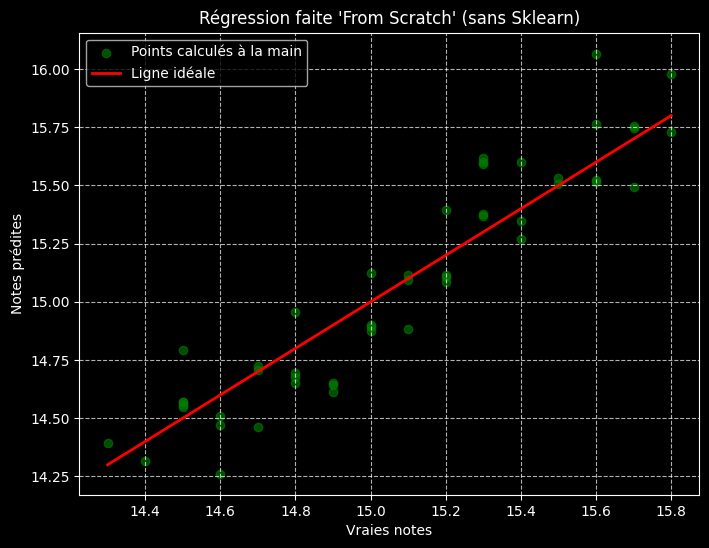

In [6]:
y_final_pred = np.dot(X_bias, poids)

plt.figure(figsize=(8, 6))
plt.scatter(y, y_final_pred, color='green', alpha=0.6, label="Points calculés à la main")
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, label="Ligne idéale")

plt.title("Régression faite 'From Scratch' (sans Sklearn)")
plt.xlabel("Vraies notes")
plt.ylabel("Notes prédites")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()